In [1]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import glob
from sklearn.decomposition import PCA
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
import os
import pandas as pd
import gc

In [2]:
hrdps = sorted(glob.glob('/results/forcing/atmospheric/GEM2.5/gemlam/gemlam_y????m??d??.nc'))
hrdps

['/results/forcing/atmospheric/GEM2.5/gemlam/gemlam_y2007m01d03.nc',
 '/results/forcing/atmospheric/GEM2.5/gemlam/gemlam_y2007m01d04.nc',
 '/results/forcing/atmospheric/GEM2.5/gemlam/gemlam_y2007m01d05.nc',
 '/results/forcing/atmospheric/GEM2.5/gemlam/gemlam_y2007m01d06.nc',
 '/results/forcing/atmospheric/GEM2.5/gemlam/gemlam_y2007m01d07.nc',
 '/results/forcing/atmospheric/GEM2.5/gemlam/gemlam_y2007m01d08.nc',
 '/results/forcing/atmospheric/GEM2.5/gemlam/gemlam_y2007m01d09.nc',
 '/results/forcing/atmospheric/GEM2.5/gemlam/gemlam_y2007m01d10.nc',
 '/results/forcing/atmospheric/GEM2.5/gemlam/gemlam_y2007m01d11.nc',
 '/results/forcing/atmospheric/GEM2.5/gemlam/gemlam_y2007m01d12.nc',
 '/results/forcing/atmospheric/GEM2.5/gemlam/gemlam_y2007m01d13.nc',
 '/results/forcing/atmospheric/GEM2.5/gemlam/gemlam_y2007m01d14.nc',
 '/results/forcing/atmospheric/GEM2.5/gemlam/gemlam_y2007m01d15.nc',
 '/results/forcing/atmospheric/GEM2.5/gemlam/gemlam_y2007m01d16.nc',
 '/results/forcing/atmospheric/GEM

In [3]:
hrdps[0]

'/results/forcing/atmospheric/GEM2.5/gemlam/gemlam_y2007m01d03.nc'

In [4]:
hrdps[-1]

'/results/forcing/atmospheric/GEM2.5/gemlam/gemlam_y2014m11d18.nc'

In [5]:
years = [2008, 2009, 2010, 2011, 2012]
original_hrdps_dir = ("/results/forcing/atmospheric/GEM2.5/gemlam")
time_fixed_dir = ("/ocean/dtaneja/MOAD/analysis-dishika/notebooks/TimeFixed")

fixed_2008_filenames = {
    "gemlam_y2008m07d16.nc",
    "gemlam_y2008m07d17.nc",
    "gemlam_y2008m07d18.nc",
    "gemlam_y2008m07d19.nc",
    "gemlam_y2008m07d20.nc",
    "gemlam_y2008m07d21.nc",
    "gemlam_y2008m07d22.nc",
    "gemlam_y2008m07d23.nc",
    'gemlam_y2008m08d10.nc',
    "gemlam_y2008m08d11.nc",
    "gemlam_y2008m08d12.nc",
}

hrdps_files_by_year = {}
for year in years:
    original_files = glob.glob(os.path.join(original_hrdps_dir,f"gemlam_y{year}m??d??.nc"))
    files_by_name = {os.path.basename(file): file for file in original_files}
    if year == 2008:
        for filename in fixed_2008_filenames:
            fixed_file = os.path.join(time_fixed_dir,filename,)
            files_by_name[filename] = fixed_file

    files = [files_by_name[filename] for filename in sorted(files_by_name)]

    hrdps_files_by_year[year] = files

    print(year,":",files[0],"to",files[-1],f"({len(files)} files)")

2008 : /results/forcing/atmospheric/GEM2.5/gemlam/gemlam_y2008m01d01.nc to /results/forcing/atmospheric/GEM2.5/gemlam/gemlam_y2008m12d31.nc (366 files)
2009 : /results/forcing/atmospheric/GEM2.5/gemlam/gemlam_y2009m01d01.nc to /results/forcing/atmospheric/GEM2.5/gemlam/gemlam_y2009m12d31.nc (365 files)
2010 : /results/forcing/atmospheric/GEM2.5/gemlam/gemlam_y2010m01d01.nc to /results/forcing/atmospheric/GEM2.5/gemlam/gemlam_y2010m12d31.nc (365 files)
2011 : /results/forcing/atmospheric/GEM2.5/gemlam/gemlam_y2011m01d01.nc to /results/forcing/atmospheric/GEM2.5/gemlam/gemlam_y2011m12d31.nc (365 files)
2012 : /results/forcing/atmospheric/GEM2.5/gemlam/gemlam_y2012m01d01.nc to /results/forcing/atmospheric/GEM2.5/gemlam/gemlam_y2012m12d31.nc (366 files)


In [6]:
# Loading darsdsets

weights_pre_file = "/home/sallen/MEOPAR/grid/weights-gem2.5-gemlam_201702_pre22sep11.nc"
weights_post_file = "/home/sallen/MEOPAR/grid/weights-gem2.5-gemlam_201702_22sep11onward.nc"
mesh_mask_file = "/ocean/dtaneja/MOAD/analysis-dishika/grid/mesh_mask202108.nc"

ds_weights_pre = xr.open_dataset(weights_pre_file).load()
ds_weights_post = xr.open_dataset(weights_post_file).load()

with xr.open_dataset(mesh_mask_file) as ds_mesh:
    nemo_lat = ds_mesh["nav_lat"].load()
    nemo_lon = ds_mesh["nav_lon"].load()

In [7]:
# Converts hourly HRDPS solar from the 266 × 256 HRDPS grid to the 898 × 398 NEMO grid

transition_time = pd.Timestamp("2011-09-22 00:00:00")

def interpolate_solar_with_weights(solar, ds_weights):
    solar = solar.transpose("time_counter", "y", "x")

    n_time = solar.sizes["time_counter"]
    source_shape = (solar.sizes["y"],solar.sizes["x"])
    n_source_cells = source_shape[0] * source_shape[1]

    source_values = (solar.values.reshape(n_time, n_source_cells).astype(np.float32))
    target_shape = ds_weights["src01"].shape

    interpolated = np.zeros((n_time, target_shape[0], target_shape[1]),dtype=np.float32)

    for n in range(1, 5):
        # The source indexes in the weights file are 1-based
        source_index = (ds_weights[f"src{n:02d}"].values.astype(np.int64)- 1)
        weight = (ds_weights[f"wgt{n:02d}"].values.astype(np.float32))

        interpolated += (source_values[:, source_index]* weight[None, :, :])

    solar_nemo = xr.DataArray(
        interpolated,
        dims=("time_counter", "y", "x"),
        coords={
            "time_counter": solar["time_counter"],
            "nav_lat": (("y", "x"), nemo_lat.values),
            "nav_lon": (("y", "x"), nemo_lon.values),
        },
        name="solar"
    )

    solar_nemo.attrs = solar.attrs.copy()
    solar_nemo.attrs["grid"] = "SalishSeaCast NEMO grid"
    solar_nemo.attrs["interpolation"] = (
        "Four-source weighted HRDPS-to-NEMO interpolation"
    )
    return solar_nemo

In [8]:
# Open file and interpolates

def extract_and_interpolate_hourly_solar(file):
    with xr.open_dataset(file) as ds:
        solar = ds["solar"].sortby("time_counter")
        time_index = solar.get_index("time_counter")

        if time_index.has_duplicates:
            unique_mask = ~time_index.duplicated()
            solar = solar.isel(time_counter=unique_mask)

        solar = solar.load()

    times = pd.to_datetime(solar["time_counter"].values)

    before_transition = times < transition_time
    after_transition = times >= transition_time

    pieces = []

    if before_transition.any():
        solar_pre = solar.isel(time_counter=np.where(before_transition)[0])
        interpolated_pre = interpolate_solar_with_weights(solar_pre,ds_weights_pre)
        pieces.append(interpolated_pre)

    if after_transition.any():
        solar_post = solar.isel(time_counter=np.where(after_transition)[0])
        interpolated_post = interpolate_solar_with_weights(solar_post,ds_weights_post)
        pieces.append(interpolated_post)

    solar_nemo = xr.concat(pieces,dim="time_counter").sortby("time_counter")
    return solar_nemo

In [9]:
sample_pre_file = hrdps_files_by_year[2008][0]
solar_nemo_pre = extract_and_interpolate_hourly_solar(sample_pre_file)

print("Shape:", solar_nemo_pre.shape)
print("Time range:",solar_nemo_pre.time_counter.values[0],"to",solar_nemo_pre.time_counter.values[-1])

Shape: (24, 898, 398)
Time range: 2008-01-01T00:00:00.000000000 to 2008-01-01T23:00:00.000000000


In [10]:
sample_post_file = hrdps_files_by_year[2012][0]
solar_nemo_post = extract_and_interpolate_hourly_solar(sample_post_file)

print("Shape:", solar_nemo_post.shape)
print("Time range:",solar_nemo_post.time_counter.values[0],"to",solar_nemo_post.time_counter.values[-1])

Shape: (24, 898, 398)
Time range: 2012-01-01T00:00:00.000000000 to 2012-01-01T23:00:00.000000000


In [11]:
with xr.open_dataset(mesh_mask_file) as ds_mesh:
    water_mask = (ds_mesh["tmask"].isel(t=0, z=0).load().values.astype(bool))
    nemo_lat_2d = ds_mesh["nav_lat"].load().values
    nemo_lon_2d = ds_mesh["nav_lon"].load().values
nemo_j, nemo_i = np.where(water_mask)
water_flat_indices = np.flatnonzero(water_mask.reshape(-1))
nemo_water_lat = nemo_lat_2d[water_mask]
nemo_water_lon = nemo_lon_2d[water_mask]
n_water = len(water_flat_indices)
print("NEMO grid shape:", water_mask.shape)
print("Number of surface water cells:", n_water)

NEMO grid shape: (898, 398)
Number of surface water cells: 81383


In [12]:
def process_daily_file_to_3h_water(file):
    solar_nemo_hourly = extract_and_interpolate_hourly_solar(file)
    n_time = solar_nemo_hourly.sizes["time_counter"]

    solar_water_values = (solar_nemo_hourly.values.reshape(n_time, -1)[:, water_flat_indices].astype(np.float32))
    solar_water_hourly = xr.DataArray(solar_water_values,dims=("time_counter", "water_cell"),coords={
            "time_counter": solar_nemo_hourly["time_counter"].values,
            "water_cell": np.arange(n_water, dtype=np.int32),},name="solar",attrs=solar_nemo_hourly.attrs,)

    solar_water_3h = solar_water_hourly.resample(time_counter="3h",label="left",closed="left",origin="start_day",).mean()
    return solar_water_3h.load()

In [13]:
test_file = hrdps_files_by_year[2008][0]

test_3h = process_daily_file_to_3h_water(test_file)

print(test_3h)
print("Shape:", test_3h.shape)
print("Times:", test_3h.time_counter.values)

<xarray.DataArray 'solar' (time_counter: 8, water_cell: 81383)> Size: 3MB
array([[ 40.349495  ,  40.572548  ,  40.795338  , ...,  26.658371  ,
         26.46128   ,  26.264038  ],
       [  0.        ,   0.        ,   0.        , ...,   0.        ,
          0.        ,   0.        ],
       [  0.        ,   0.        ,   0.        , ...,   0.        ,
          0.        ,   0.        ],
       ...,
       [  9.487893  ,   9.608655  ,   9.729562  , ...,   0.6429294 ,
          0.64058906,   0.6368155 ],
       [146.41951   , 147.54872   , 148.68095   , ...,  17.668282  ,
         17.710564  ,  17.762838  ],
       [171.4248    , 172.30855   , 173.18086   , ...,  22.956892  ,
         23.102015  ,  23.265722  ]], shape=(8, 81383), dtype=float32)
Coordinates:
  * time_counter  (time_counter) datetime64[ns] 64B 2008-01-01 ... 2008-01-01...
  * water_cell    (water_cell) int32 326kB 0 1 2 3 4 ... 81379 81380 81381 81382
Attributes:
    level:          surface
    long_name:      Downward 

In [14]:
# # Run only once
# output_dir = ("/ocean/dtaneja/MOAD/analysis-dishika/notebooks/data/hrdps_nemo_3h")
# os.makedirs(output_dir, exist_ok=True)
# hrdps_nemo_processed_files = []

# for year in years:
#     files = sorted(hrdps_files_by_year[year])
#     print(f"\nProcessing {year}: {len(files)} daily files")
#     daily_3h_results = []
#     for file_number, file in enumerate(files, start=1):
#         daily_3h = process_daily_file_to_3h_water(file)
#         daily_3h_results.append(daily_3h)

#         if (file_number == 1 or file_number % 25 == 0 or file_number == len(files)):
#             print(f"{year}: processed "f"{file_number}/{len(files)} files")

#     solar_year = xr.concat(daily_3h_results,dim="time_counter",)
#     solar_year = solar_year.sortby("time_counter")
#     time_index = solar_year.get_index("time_counter")

#     if time_index.has_duplicates:
#         unique_mask = ~time_index.duplicated()
#         solar_year = solar_year.isel(time_counter=unique_mask)

#     ds_year = solar_year.to_dataset(name="solar")

#     ds_year = ds_year.assign_coords(
#         nemo_j=("water_cell",nemo_j.astype(np.int32),),
#         nemo_i=("water_cell",nemo_i.astype(np.int32),),
#         nav_lat=("water_cell",nemo_water_lat.astype(np.float32),),
#         nav_lon=("water_cell",nemo_water_lon.astype(np.float32),),)

#     ds_year.attrs["description"] = ("Raw hourly HRDPS solar interpolated onto NEMO surface water cells, then resampled to three-hourly means.")

#     output_file = (f"{output_dir}/"f"HRDPS_NEMO_{year}_solar_3h.nc")
#     encoding = {"solar": {"dtype": "float32","zlib": True,"complevel": 4,}}
#     ds_year.to_netcdf(output_file,engine="netcdf4",encoding=encoding,)
#     hrdps_nemo_processed_files.append(output_file)

#     print("Saved:", output_file)
#     print("Shape:", ds_year["solar"].shape)
#     print("Time range:",ds_year.time_counter.values[0],"to",ds_year.time_counter.values[-1],)
#     del daily_3h_results
#     del solar_year
#     del ds_year

#     gc.collect()

In [15]:
# Run only once
output_dir = ("/ocean/dtaneja/MOAD/analysis-dishika/notebooks/data/hrdps_nemo_3h")
os.makedirs(output_dir, exist_ok=True)
hrdps_nemo_processed_files = []

for year in [2008]:
    files = hrdps_files_by_year[year]
    print(f"\nProcessing {year}: {len(files)} daily files")
    daily_3h_results = []
    for file_number, file in enumerate(files, start=1):
        daily_3h = process_daily_file_to_3h_water(file)
        daily_3h_results.append(daily_3h)

        if (file_number == 1 or file_number % 25 == 0 or file_number == len(files)):
            print(f"{year}: processed "f"{file_number}/{len(files)} files")

    solar_year = xr.concat(daily_3h_results,dim="time_counter",)
    solar_year = solar_year.sortby("time_counter")
    time_index = solar_year.get_index("time_counter")

    if time_index.has_duplicates:
        unique_mask = ~time_index.duplicated()
        solar_year = solar_year.isel(time_counter=unique_mask)

    ds_year = solar_year.to_dataset(name="solar")

    ds_year = ds_year.assign_coords(
        nemo_j=("water_cell",nemo_j.astype(np.int32),),
        nemo_i=("water_cell",nemo_i.astype(np.int32),),
        nav_lat=("water_cell",nemo_water_lat.astype(np.float32),),
        nav_lon=("water_cell",nemo_water_lon.astype(np.float32),),)

    ds_year.attrs["description"] = ("Raw hourly HRDPS solar interpolated onto NEMO surface water cells, then resampled to three-hourly means.")

    output_file = (f"{output_dir}/"f"HRDPS_NEMO_{year}_solar_3h.nc")
    encoding = {"solar": {"dtype": "float32","zlib": True,"complevel": 4,}}
    ds_year.to_netcdf(output_file,engine="netcdf4",encoding=encoding,)
    hrdps_nemo_processed_files.append(output_file)

    print("Saved:", output_file)
    print("Shape:", ds_year["solar"].shape)
    print("Time range:",ds_year.time_counter.values[0],"to",ds_year.time_counter.values[-1],)
    del daily_3h_results
    del solar_year
    del ds_year

    gc.collect()


Processing 2008: 366 daily files
2008: processed 1/366 files
2008: processed 25/366 files
2008: processed 50/366 files
2008: processed 75/366 files
2008: processed 100/366 files
2008: processed 125/366 files
2008: processed 150/366 files
2008: processed 175/366 files
2008: processed 200/366 files
2008: processed 225/366 files
2008: processed 250/366 files
2008: processed 275/366 files
2008: processed 300/366 files
2008: processed 325/366 files
2008: processed 350/366 files
2008: processed 366/366 files
Saved: /ocean/dtaneja/MOAD/analysis-dishika/notebooks/data/hrdps_nemo_3h/HRDPS_NEMO_2008_solar_3h.nc
Shape: (2928, 81383)
Time range: 2008-01-01T00:00:00.000000000 to 2008-12-31T21:00:00.000000000


In [16]:
hrdps_nemo_files = sorted(glob.glob("/ocean/dtaneja/MOAD/analysis-dishika/notebooks/data/hrdps_nemo_3h/HRDPS_NEMO_*_solar_3h.nc"))
ds_hrdps_nemo = xr.open_mfdataset(hrdps_nemo_files,combine="by_coords")

ds_hrdps_nemo = ds_hrdps_nemo.sortby("time_counter")

print(ds_hrdps_nemo)
print("First time:", ds_hrdps_nemo.time_counter.values[0])
print("Last time: ", ds_hrdps_nemo.time_counter.values[-1])
print("Shape:", ds_hrdps_nemo["solar"].shape)

<xarray.Dataset> Size: 5GB
Dimensions:       (time_counter: 14608, water_cell: 81383)
Coordinates:
  * time_counter  (time_counter) datetime64[ns] 117kB 2008-01-01 ... 2012-12-...
  * water_cell    (water_cell) int32 326kB 0 1 2 3 4 ... 81379 81380 81381 81382
    nemo_j        (water_cell) int32 326kB dask.array<chunksize=(81383,), meta=np.ndarray>
    nemo_i        (water_cell) int32 326kB dask.array<chunksize=(81383,), meta=np.ndarray>
    nav_lat       (water_cell) float32 326kB dask.array<chunksize=(81383,), meta=np.ndarray>
    nav_lon       (water_cell) float32 326kB dask.array<chunksize=(81383,), meta=np.ndarray>
Data variables:
    solar         (time_counter, water_cell) float32 5GB dask.array<chunksize=(366, 10173), meta=np.ndarray>
Attributes:
    description:  Raw hourly HRDPS solar interpolated onto NEMO surface water...
First time: 2008-01-01T00:00:00.000000000
Last time:  2012-12-31T21:00:00.000000000
Shape: (14608, 81383)


In [17]:
# Validation: 2008
ds_hrdps_val = ds_hrdps_nemo.sel(time_counter=slice("2008-01-01", "2008-12-31 23:59:59"))
# Training: 2009–2011
ds_hrdps_train = ds_hrdps_nemo.sel(time_counter=slice("2009-01-01", "2011-12-31 23:59:59"))
# Testing: 2012
ds_hrdps_test = ds_hrdps_nemo.sel(time_counter=slice("2012-01-01", "2012-12-31 23:59:59"))

In [18]:
canrcm_years = [2008, 2009, 2010, 2011, 2012]
canrcm_rsds_files = []

for year in canrcm_years:
    matches = sorted(glob.glob(f"/results/forcing/CanRCM5/*_{year}01_{year}12_3h_rsds.nc"))
    canrcm_rsds_files.append(matches[0])

print("CanRCM files:")
for file in canrcm_rsds_files:
    print(file)

CanRCM files:
/results/forcing/CanRCM5/sc_nam22r55lkn3-bc07_200801_200812_3h_rsds.nc
/results/forcing/CanRCM5/sc_nam22r55lkn3-bc07_200901_200912_3h_rsds.nc
/results/forcing/CanRCM5/sc_nam22r55lkn3-bc07_201001_201012_3h_rsds.nc
/results/forcing/CanRCM5/sc_nam22r55lkn3-bc07_201101_201112_3h_rsds.nc
/results/forcing/CanRCM5/sc_nam22r55lkn3-bc07_201201_201212_3h_rsds.nc


In [19]:
from datetime import timedelta
ds_canrcm = xr.open_mfdataset(canrcm_rsds_files,combine="by_coords")
ds_canrcm = ds_canrcm.sortby("time")
shifted_time = np.array([time_value - timedelta(hours=3)for time_value in ds_canrcm["time"].values])
ds_canrcm = ds_canrcm.assign_coords(time=("time", shifted_time))

print(ds_canrcm)
print("First timestamp:", ds_canrcm.time.values[0])
print("Last timestamp: ", ds_canrcm.time.values[-1])

<xarray.Dataset> Size: 7GB
Dimensions:       (time: 14600, bnds: 2, rlat: 320, rlon: 360)
Coordinates:
  * time          (time) object 117kB 2008-01-01 00:00:00 ... 2012-12-31 21:0...
  * rlat          (rlat) float64 3kB -35.11 -34.89 -34.67 ... 34.63 34.85 35.07
  * rlon          (rlon) float64 3kB -39.27 -39.05 -38.83 ... 39.27 39.49 39.71
    lon           (rlat, rlon) float64 922kB dask.array<chunksize=(320, 360), meta=np.ndarray>
    lat           (rlat, rlon) float64 922kB dask.array<chunksize=(320, 360), meta=np.ndarray>
Dimensions without coordinates: bnds
Data variables:
    time_bnds     (time, bnds) object 234kB dask.array<chunksize=(2920, 2), meta=np.ndarray>
    rotated_pole  (time) |S1 15kB b'' b'' b'' b'' b'' ... b'' b'' b'' b'' b''
    rsds          (time, rlat, rlon) float32 7GB dask.array<chunksize=(2920, 320, 360), meta=np.ndarray>
Attributes: (12/17)
    title:                          CanRCM4 model output prepared for CORDEX ...
    institution:                    

/tmp/ipykernel_794706/2396138099.py:2: FutureWarning: In a future version of xarray the default value for data_vars will change from data_vars='all' to data_vars=None. This is likely to lead to different results when multiple datasets have matching variables with overlapping values. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set data_vars explicitly.
  ds_canrcm = xr.open_mfdataset(canrcm_rsds_files,combine="by_coords")


In [20]:
nemo_water_lat = ds_hrdps_nemo["nav_lat"].values
nemo_water_lon = ds_hrdps_nemo["nav_lon"].values

nemo_water_lon_normalized = ((nemo_water_lon + 180) % 360) - 180

lat_min = float(np.nanmin(nemo_water_lat))
lat_max = float(np.nanmax(nemo_water_lat))

lon_min = float(np.nanmin(nemo_water_lon_normalized))
lon_max = float(np.nanmax(nemo_water_lon_normalized))

print("NEMO latitude range:", lat_min, "to", lat_max)
print("NEMO longitude range:", lon_min, "to", lon_max)

NEMO latitude range: 47.06300735473633 to 50.92766571044922
NEMO longitude range: -126.14797973632812 to -122.22117614746094


In [21]:
lat_canrcm = ds_canrcm["lat"]
lon_canrcm = ds_canrcm["lon"]

lon_canrcm_normalized = ((lon_canrcm + 180) % 360) - 180
canrcm_region_mask = ((lat_canrcm >= lat_min)& (lat_canrcm <= lat_max)
                      & (lon_canrcm_normalized >= lon_min) & (lon_canrcm_normalized <= lon_max))

rlat_indices, rlon_indices = np.where(canrcm_region_mask.values)

rlat_min = rlat_indices.min()
rlat_max = rlat_indices.max()

rlon_min = rlon_indices.min()
rlon_max = rlon_indices.max()

print("CanRCM rlat indices:", rlat_min, "to", rlat_max)
print("CanRCM rlon indices:", rlon_min, "to", rlon_max)

ds_canrcm_cut = (ds_canrcm[["rsds"]].isel(rlat=slice(rlat_min, rlat_max + 1),rlon=slice(rlon_min, rlon_max + 1)))
print(ds_canrcm_cut)

CanRCM rlat indices: 171 to 190
CanRCM rlon indices: 91 to 107
<xarray.Dataset> Size: 20MB
Dimensions:  (time: 14600, rlat: 20, rlon: 17)
Coordinates:
  * time     (time) object 117kB 2008-01-01 00:00:00 ... 2012-12-31 21:00:00
  * rlat     (rlat) float64 160B 2.51 2.73 2.95 3.17 ... 6.03 6.25 6.47 6.69
  * rlon     (rlon) float64 136B -19.25 -19.03 -18.81 ... -16.17 -15.95 -15.73
    lon      (rlat, rlon) float64 3kB dask.array<chunksize=(20, 17), meta=np.ndarray>
    lat      (rlat, rlon) float64 3kB dask.array<chunksize=(20, 17), meta=np.ndarray>
Data variables:
    rsds     (time, rlat, rlon) float32 20MB dask.array<chunksize=(2920, 20, 17), meta=np.ndarray>
Attributes: (12/17)
    title:                          CanRCM4 model output prepared for CORDEX ...
    institution:                    CCCma (Canadian Centre for Climate Modell...
    institute_id:                   CCCma
    driving_experiment:             , , r1i1p1
    driving_model_ensemble_member:  r1i1p1
    realization

In [22]:
# Validation: 2008
ds_canrcm_val = ds_canrcm_cut.sel(time=slice("2008-01-01","2008-12-31 23:59:59"))
# Training: 2009–2011
ds_canrcm_train = ds_canrcm_cut.sel(time=slice("2009-01-01","2011-12-31 23:59:59"))
# Testing: 2012
ds_canrcm_test = ds_canrcm_cut.sel(time=slice("2012-01-01","2012-12-31 23:59:59"))

In [23]:
def time_to_string(value):
    if isinstance(value, np.datetime64):
        return np.datetime_as_string(value,unit="s").replace("T", " ")

    if hasattr(value, "strftime"):
        return value.strftime("%Y-%m-%d %H:%M:%S")

    raise TypeError(f"Unsupported time type: {type(value)}")


def align_time_pair(ds_canrcm_split, ds_hrdps_split):
    canrcm_times = np.array([time_to_string(t)for t in ds_canrcm_split["time"].values])
    hrdps_times = np.array([time_to_string(t)for t in ds_hrdps_split["time_counter"].values])
    common_times, canrcm_idx, hrdps_idx = np.intersect1d(canrcm_times,hrdps_times,return_indices=True)
    ds_canrcm_aligned = ds_canrcm_split.isel(time=canrcm_idx)
    ds_hrdps_aligned = ds_hrdps_split.isel(time_counter=hrdps_idx)
    return ds_canrcm_aligned, ds_hrdps_aligned

In [24]:
canrcm_times = np.array([time_to_string(time) for time in ds_canrcm_val["time"].values])
hrdps_times = np.array([time_to_string(time) for time in ds_hrdps_val["time_counter"].values])

canrcm_not_in_hrdps = np.setdiff1d(canrcm_times, hrdps_times)
hrdps_not_in_canrcm = np.setdiff1d(hrdps_times, canrcm_times)

print("CanRCM timestamps not in HRDPS:", len(canrcm_not_in_hrdps))
print(canrcm_not_in_hrdps)

print("\nHRDPS timestamps not in CanRCM:", len(hrdps_not_in_canrcm))
print(hrdps_not_in_canrcm)

CanRCM timestamps not in HRDPS: 0
[]

HRDPS timestamps not in CanRCM: 8
['2008-02-29 00:00:00' '2008-02-29 03:00:00' '2008-02-29 06:00:00'
 '2008-02-29 09:00:00' '2008-02-29 12:00:00' '2008-02-29 15:00:00'
 '2008-02-29 18:00:00' '2008-02-29 21:00:00']


In [25]:
ds_canrcm_val, ds_hrdps_val = align_time_pair(ds_canrcm_val,ds_hrdps_val)
ds_canrcm_train, ds_hrdps_train = align_time_pair(ds_canrcm_train,ds_hrdps_train)
ds_canrcm_test, ds_hrdps_test = align_time_pair(ds_canrcm_test,ds_hrdps_test)

In [26]:
print("Validation:")
print("HRDPS:", ds_hrdps_val.sizes["time_counter"])
print("CanRCM:", ds_canrcm_val.sizes["time"])

print("\nTraining:")
print("HRDPS:", ds_hrdps_train.sizes["time_counter"])
print("CanRCM:", ds_canrcm_train.sizes["time"])

print("\nTesting:")
print("HRDPS:", ds_hrdps_test.sizes["time_counter"])
print("CanRCM:", ds_canrcm_test.sizes["time"])

assert ds_hrdps_val.sizes["time_counter"] == ds_canrcm_val.sizes["time"]
assert ds_hrdps_train.sizes["time_counter"] == ds_canrcm_train.sizes["time"]
assert ds_hrdps_test.sizes["time_counter"] == ds_canrcm_test.sizes["time"]

Validation:
HRDPS: 2920
CanRCM: 2920

Training:
HRDPS: 8760
CanRCM: 8760

Testing:
HRDPS: 2912
CanRCM: 2912


In [27]:
X_hrdps_train_raw = (ds_hrdps_train["solar"].values.astype(np.float32))
X_hrdps_val_raw = (ds_hrdps_val["solar"].values.astype(np.float32))
X_hrdps_test_raw = (ds_hrdps_test["solar"].values.astype(np.float32))

print("Raw HRDPS-NEMO train:", X_hrdps_train_raw.shape)
print("Raw HRDPS-NEMO val:  ", X_hrdps_val_raw.shape)
print("Raw HRDPS-NEMO test: ", X_hrdps_test_raw.shape)

Raw HRDPS-NEMO train: (8760, 81383)
Raw HRDPS-NEMO val:   (2920, 81383)
Raw HRDPS-NEMO test:  (2912, 81383)


In [28]:
valid_fraction_hrdps = np.isfinite(X_hrdps_train_raw).mean(axis=0)
valid_nemo_cols = valid_fraction_hrdps > 0.95

X_hrdps_train = X_hrdps_train_raw[:, valid_nemo_cols].copy()
X_hrdps_val = X_hrdps_val_raw[:, valid_nemo_cols].copy()
X_hrdps_test = X_hrdps_test_raw[:, valid_nemo_cols].copy()

hrdps_col_mean = np.nanmean(X_hrdps_train,axis=0)

if not np.all(np.isfinite(hrdps_col_mean)):
    raise ValueError(
        "At least one retained NEMO cell has a non-finite training mean."
    )


def fill_with_training_mean(X, training_mean):
    X = X.copy()
    rows, cols = np.where(~np.isfinite(X))
    X[rows, cols] = training_mean[cols]
    return X


X_hrdps_train = fill_with_training_mean(X_hrdps_train,hrdps_col_mean)
X_hrdps_val = fill_with_training_mean(X_hrdps_val,hrdps_col_mean)
X_hrdps_test = fill_with_training_mean(X_hrdps_test,hrdps_col_mean)

print("Valid NEMO cells:", valid_nemo_cols.sum())
print("Final HRDPS train:", X_hrdps_train.shape)
print("Final HRDPS val:  ", X_hrdps_val.shape)
print("Final HRDPS test: ", X_hrdps_test.shape)

Valid NEMO cells: 81383
Final HRDPS train: (8760, 81383)
Final HRDPS val:   (2920, 81383)
Final HRDPS test:  (2912, 81383)


In [29]:
valid_water_cell = (ds_hrdps_train["water_cell"].values[valid_nemo_cols])
valid_nemo_j = (ds_hrdps_train["nemo_j"].values[valid_nemo_cols])
valid_nemo_i = (ds_hrdps_train["nemo_i"].values[valid_nemo_cols])
valid_nemo_lat = (ds_hrdps_train["nav_lat"].values[valid_nemo_cols])
valid_nemo_lon = (ds_hrdps_train["nav_lon"].values[valid_nemo_cols])
print("Saved coordinate count:", len(valid_water_cell))

Saved coordinate count: 81383


In [30]:
def make_canrcm_matrix(da):
    da = da.transpose("time", "rlat", "rlon")
    n_time = da.sizes["time"]
    return (da.values.reshape(n_time, -1).astype(np.float32))

X_canrcm_train_raw = make_canrcm_matrix(ds_canrcm_train["rsds"])
X_canrcm_val_raw = make_canrcm_matrix(ds_canrcm_val["rsds"])
X_canrcm_test_raw = make_canrcm_matrix(ds_canrcm_test["rsds"])

print("Raw CanRCM train:", X_canrcm_train_raw.shape)
print("Raw CanRCM val:  ", X_canrcm_val_raw.shape)
print("Raw CanRCM test: ", X_canrcm_test_raw.shape)

Raw CanRCM train: (8760, 340)
Raw CanRCM val:   (2920, 340)
Raw CanRCM test:  (2912, 340)


In [31]:
valid_fraction_canrcm = np.isfinite(X_canrcm_train_raw).mean(axis=0)
valid_canrcm_cols = valid_fraction_canrcm > 0.95

X_canrcm_train = X_canrcm_train_raw[:,valid_canrcm_cols].copy()
X_canrcm_val = X_canrcm_val_raw[:,valid_canrcm_cols].copy()
X_canrcm_test = X_canrcm_test_raw[:,valid_canrcm_cols].copy()
canrcm_col_mean = np.nanmean(X_canrcm_train,axis=0)

if not np.all(np.isfinite(canrcm_col_mean)):
    raise ValueError(
        "At least one retained CanRCM cell has a non-finite training mean."
    )

X_canrcm_train = fill_with_training_mean(X_canrcm_train,canrcm_col_mean)
X_canrcm_val = fill_with_training_mean(X_canrcm_val,canrcm_col_mean)
X_canrcm_test = fill_with_training_mean(X_canrcm_test,canrcm_col_mean)
print("Final CanRCM train:", X_canrcm_train.shape)
print("Final CanRCM val:  ", X_canrcm_val.shape)
print("Final CanRCM test: ", X_canrcm_test.shape)

Final CanRCM train: (8760, 340)
Final CanRCM val:   (2920, 340)
Final CanRCM test:  (2912, 340)


In [32]:
hrdps_variance_threshold = 0.98
max_hrdps_pcs = min(300,X_hrdps_train.shape[0] - 1,X_hrdps_train.shape[1])
pca_hrdps = PCA(n_components=max_hrdps_pcs,svd_solver="randomized",random_state=0)
hrdps_train_scores_all = pca_hrdps.fit_transform(X_hrdps_train)
hrdps_cumulative_variance = np.cumsum(pca_hrdps.explained_variance_ratio_)
print("HRDPS PCA components:", pca_hrdps.components_.shape)
print("HRDPS training scores:", hrdps_train_scores_all.shape)
print("Variance explained by all searched PCs:",hrdps_cumulative_variance[-1])

HRDPS PCA components: (300, 81383)
HRDPS training scores: (8760, 300)
Variance explained by all searched PCs: 0.9996387


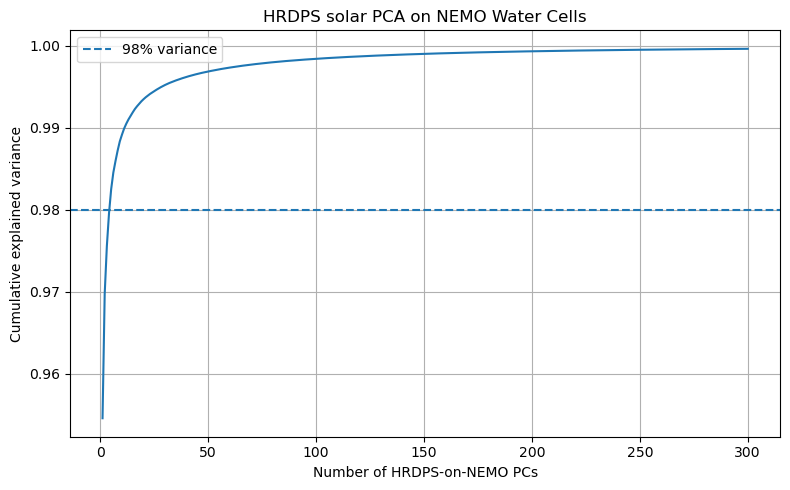

In [33]:
plt.figure(figsize=(8, 5))
plt.plot(np.arange(1, len(hrdps_cumulative_variance) + 1),hrdps_cumulative_variance)
plt.axhline(hrdps_variance_threshold,linestyle="--",label="98% variance")
plt.xlabel("Number of HRDPS-on-NEMO PCs")
plt.ylabel("Cumulative explained variance")
plt.title("HRDPS solar PCA on NEMO Water Cells")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [34]:
threshold_indices = np.where(hrdps_cumulative_variance >= hrdps_variance_threshold)[0]
n_hrdps_pcs = threshold_indices[0] + 1
print("Selected HRDPS PCs:", n_hrdps_pcs)
print("Cumulative variance:",hrdps_cumulative_variance[n_hrdps_pcs - 1])

Selected HRDPS PCs: 5
Cumulative variance: 0.98251903


In [35]:
hrdps_train_scores = hrdps_train_scores_all[:, :n_hrdps_pcs]
hrdps_val_scores = pca_hrdps.transform(X_hrdps_val)[:, :n_hrdps_pcs]
hrdps_test_scores = pca_hrdps.transform(X_hrdps_test)[:, :n_hrdps_pcs]

print("HRDPS train scores:", hrdps_train_scores.shape)
print("HRDPS val scores:  ", hrdps_val_scores.shape)
print("HRDPS test scores: ", hrdps_test_scores.shape)

HRDPS train scores: (8760, 5)
HRDPS val scores:   (2920, 5)
HRDPS test scores:  (2912, 5)


In [36]:
max_canrcm_pcs = min(100,X_canrcm_train.shape[0] - 1,X_canrcm_train.shape[1])
pca_canrcm = PCA(n_components=max_canrcm_pcs,svd_solver="randomized",random_state=0)
canrcm_train_scores_all = pca_canrcm.fit_transform(X_canrcm_train)
canrcm_val_scores_all = pca_canrcm.transform(X_canrcm_val)
canrcm_test_scores_all = pca_canrcm.transform(X_canrcm_test)
canrcm_cumulative_variance = np.cumsum(pca_canrcm.explained_variance_ratio_)

print("CanRCM PCA components:", pca_canrcm.components_.shape)
print("CanRCM train scores:", canrcm_train_scores_all.shape)
print("CanRCM val scores:  ", canrcm_val_scores_all.shape)
print("CanRCM test scores: ", canrcm_test_scores_all.shape)

CanRCM PCA components: (100, 340)
CanRCM train scores: (8760, 100)
CanRCM val scores:   (2920, 100)
CanRCM test scores:  (2912, 100)


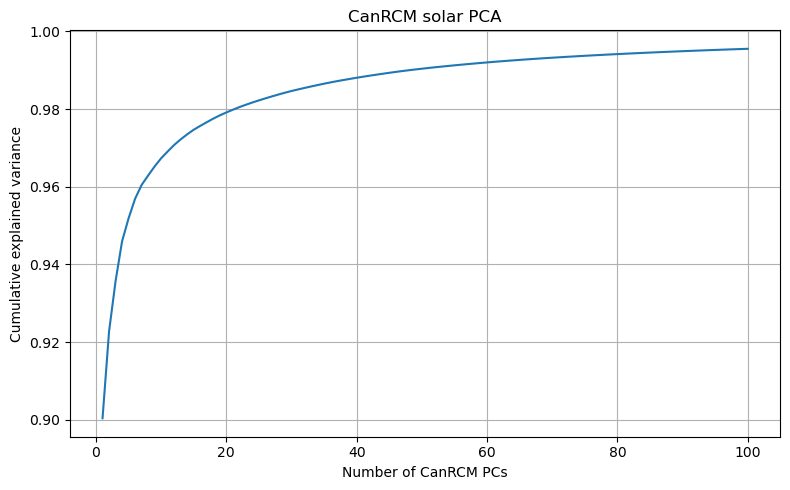

In [37]:
plt.figure(figsize=(8, 5))
plt.plot(np.arange(1, len(canrcm_cumulative_variance) + 1),canrcm_cumulative_variance)
plt.xlabel("Number of CanRCM PCs")
plt.ylabel("Cumulative explained variance")
plt.title("CanRCM solar PCA")
plt.grid(True)
plt.tight_layout()
plt.show()

In [38]:
canrcm_pc_candidates = range(1,max_canrcm_pcs + 1)
val_r2_scores = []
for n_canrcm_pcs_candidate in canrcm_pc_candidates:
    X_train_pc = canrcm_train_scores_all[:,:n_canrcm_pcs_candidate]
    X_val_pc = canrcm_val_scores_all[:,:n_canrcm_pcs_candidate]
    model = LinearRegression()
    model.fit(X_train_pc,hrdps_train_scores)
    hrdps_val_scores_pred_candidate = model.predict(X_val_pc)
    val_r2 = r2_score(hrdps_val_scores,hrdps_val_scores_pred_candidate,multioutput="variance_weighted")
    val_r2_scores.append(val_r2)
val_r2_scores = np.array(val_r2_scores)

In [39]:
best_index = np.nanargmax(val_r2_scores)
n_canrcm_pcs = list(canrcm_pc_candidates)[best_index]
best_val_r2 = val_r2_scores[best_index]

print("Best number of CanRCM PCs:", n_canrcm_pcs)
print("Best validation PC-space R²:", best_val_r2)

Best number of CanRCM PCs: 93
Best validation PC-space R²: 0.8970229029655457


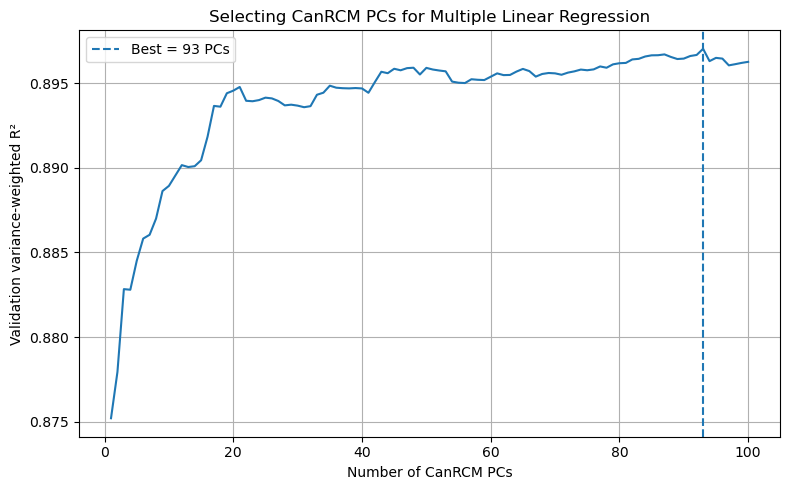

In [40]:
plt.figure(figsize=(8, 5))
plt.plot(list(canrcm_pc_candidates),val_r2_scores)
plt.axvline(n_canrcm_pcs,linestyle="--",label=f"Best = {n_canrcm_pcs} PCs")
plt.xlabel("Number of CanRCM PCs")
plt.ylabel("Validation variance-weighted R²")
plt.title("Selecting CanRCM PCs for Multiple Linear Regression")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [41]:
X_train_pc_final = canrcm_train_scores_all[:,:n_canrcm_pcs]
X_val_pc_final = canrcm_val_scores_all[:,:n_canrcm_pcs]
X_test_pc_final = canrcm_test_scores_all[:,:n_canrcm_pcs]
lr_model = LinearRegression()
lr_model.fit(X_train_pc_final,hrdps_train_scores)

hrdps_train_scores_pred = lr_model.predict(X_train_pc_final)
hrdps_val_scores_pred = lr_model.predict(X_val_pc_final)
hrdps_test_scores_pred = lr_model.predict(X_test_pc_final)

print("Regression coefficient shape:", lr_model.coef_.shape)
print("Predicted HRDPS train scores:",hrdps_train_scores_pred.shape)
print("Predicted HRDPS validation scores:",hrdps_val_scores_pred.shape)
print("Predicted HRDPS test scores:",hrdps_test_scores_pred.shape)

Regression coefficient shape: (5, 93)
Predicted HRDPS train scores: (8760, 5)
Predicted HRDPS validation scores: (2920, 5)
Predicted HRDPS test scores: (2912, 5)


In [42]:
def inverse_from_selected_hrdps_pcs(scores, pca, n_pcs):
    reconstructed = np.dot(scores,pca.components_[:n_pcs, :])
    reconstructed = reconstructed + pca.mean_
    return reconstructed.astype(np.float32)

In [43]:
X_hrdps_val_pred = inverse_from_selected_hrdps_pcs(hrdps_val_scores_pred,pca_hrdps,n_hrdps_pcs)
X_hrdps_test_pred = inverse_from_selected_hrdps_pcs(hrdps_test_scores_pred,pca_hrdps,n_hrdps_pcs)
print("Actual validation matrix:", X_hrdps_val.shape)
print("Predicted validation matrix:", X_hrdps_val_pred.shape)
print("Actual test matrix:", X_hrdps_test.shape)
print("Predicted test matrix:", X_hrdps_test_pred.shape)

Actual validation matrix: (2920, 81383)
Predicted validation matrix: (2920, 81383)
Actual test matrix: (2912, 81383)
Predicted test matrix: (2912, 81383)


In [44]:
def calculate_metrics(actual, predicted, label):
    rmse = np.sqrt(mean_squared_error(actual.ravel(),predicted.ravel()))
    mae = mean_absolute_error(actual.ravel(),predicted.ravel())
    bias = np.mean(predicted - actual)
    r2 = r2_score(actual,predicted,multioutput="variance_weighted")
    actual_std = np.std(actual, ddof=0)
    normalized_rmse = rmse / actual_std
    print(f"\n{label}")
    print("RMSE:", rmse)
    print("MAE: ", mae)
    print("Bias:", bias)
    print("R²:  ", r2)
    print("Actual standard deviation:", actual_std)
    print("Normalized RMSE:", normalized_rmse)
    print("Normalized RMSE (%):", normalized_rmse * 100)
    return {"RMSE": rmse,"MAE": mae,"Bias": bias,"R2": r2,"Normalized_RMSE": normalized_rmse,"Normalized_RMSE_percent": normalized_rmse * 100}

In [45]:
val_metrics = calculate_metrics(X_hrdps_val, X_hrdps_val_pred, "Validation metrics on NEMO water cells")
test_metrics = calculate_metrics(X_hrdps_test,X_hrdps_test_pred,"Test metrics on NEMO water cells")


Validation metrics on NEMO water cells
RMSE: 84.58363383823877
MAE:  47.945247650146484
Bias: -5.224574
R²:   0.878828763961792
Actual standard deviation: 243.0444
Normalized RMSE: 0.34801720495381927
Normalized RMSE (%): 34.80172049538193

Test metrics on NEMO water cells
RMSE: 86.93575607075462
MAE:  46.75675582885742
Bias: 4.8068633
R²:   0.8577747344970703
Actual standard deviation: 230.58049
Normalized RMSE: 0.3770299734743923
Normalized RMSE (%): 37.70299734743923


In [46]:
test_pc_r2 = r2_score(hrdps_test_scores,hrdps_test_scores_pred,multioutput="variance_weighted")
print("Test PC-space variance-weighted R²:", test_pc_r2)

Test PC-space variance-weighted R²: 0.8793846964836121


In [47]:
def nemo_vector_to_map(vector):
    nemo_map = np.full(water_mask.shape,np.nan,dtype=np.float32)
    nemo_map[valid_nemo_j,valid_nemo_i] = vector
    return nemo_map

In [48]:
def plot_actual_predicted_error(time_index,X_actual,X_predicted,times):
    actual_map = nemo_vector_to_map(X_actual[time_index])
    predicted_map = nemo_vector_to_map(X_predicted[time_index])
    error_map = predicted_map - actual_map
    solar_min = np.nanmin(np.stack([actual_map, predicted_map]))
    solar_max = np.nanmax(np.stack([actual_map, predicted_map]))
    error_limit = np.nanmax(np.abs(error_map))
    timestamp = pd.Timestamp(times[time_index])
    fig, axes = plt.subplots(1,3,figsize=(18, 8))

    p0 = axes[0].pcolormesh(actual_map,shading="auto",vmin=solar_min,vmax=solar_max)
    axes[0].set_title(f"Actual HRDPS on NEMO Grid\n{timestamp}")
    plt.colorbar(p0,ax=axes[0],label="solar (W/m^2)")

    p1 = axes[1].pcolormesh(predicted_map,shading="auto",vmin=solar_min,vmax=solar_max )
    axes[1].set_title(f"Predicted PCA + MLR\n{timestamp}")
    plt.colorbar(p1,ax=axes[1],label="solar (W/m^2)")

    p2 = axes[2].pcolormesh(error_map,shading="auto",cmap="RdBu_r",vmin=-error_limit,vmax=error_limit)
    axes[2].set_title(f"Predicted − Actual\n{timestamp}")
    plt.colorbar(p2,ax=axes[2],label="Error (W/m^2)")

    for ax in axes:
        ax.set_xlabel("NEMO x index (i)")
        ax.set_ylabel("NEMO y index (j)")

    plt.tight_layout()
    plt.show()

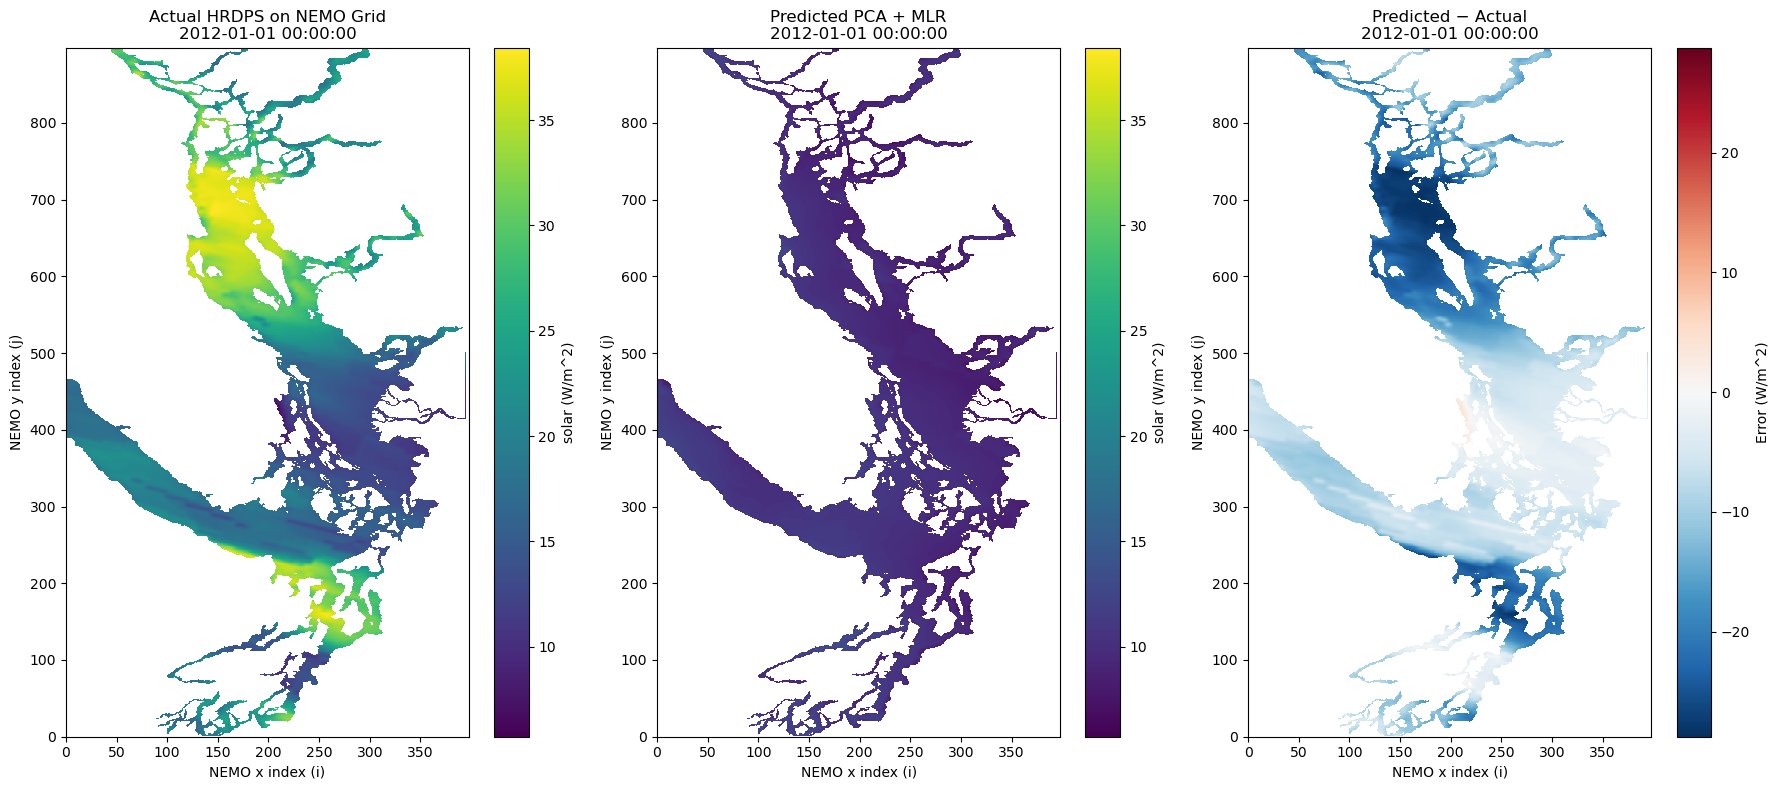

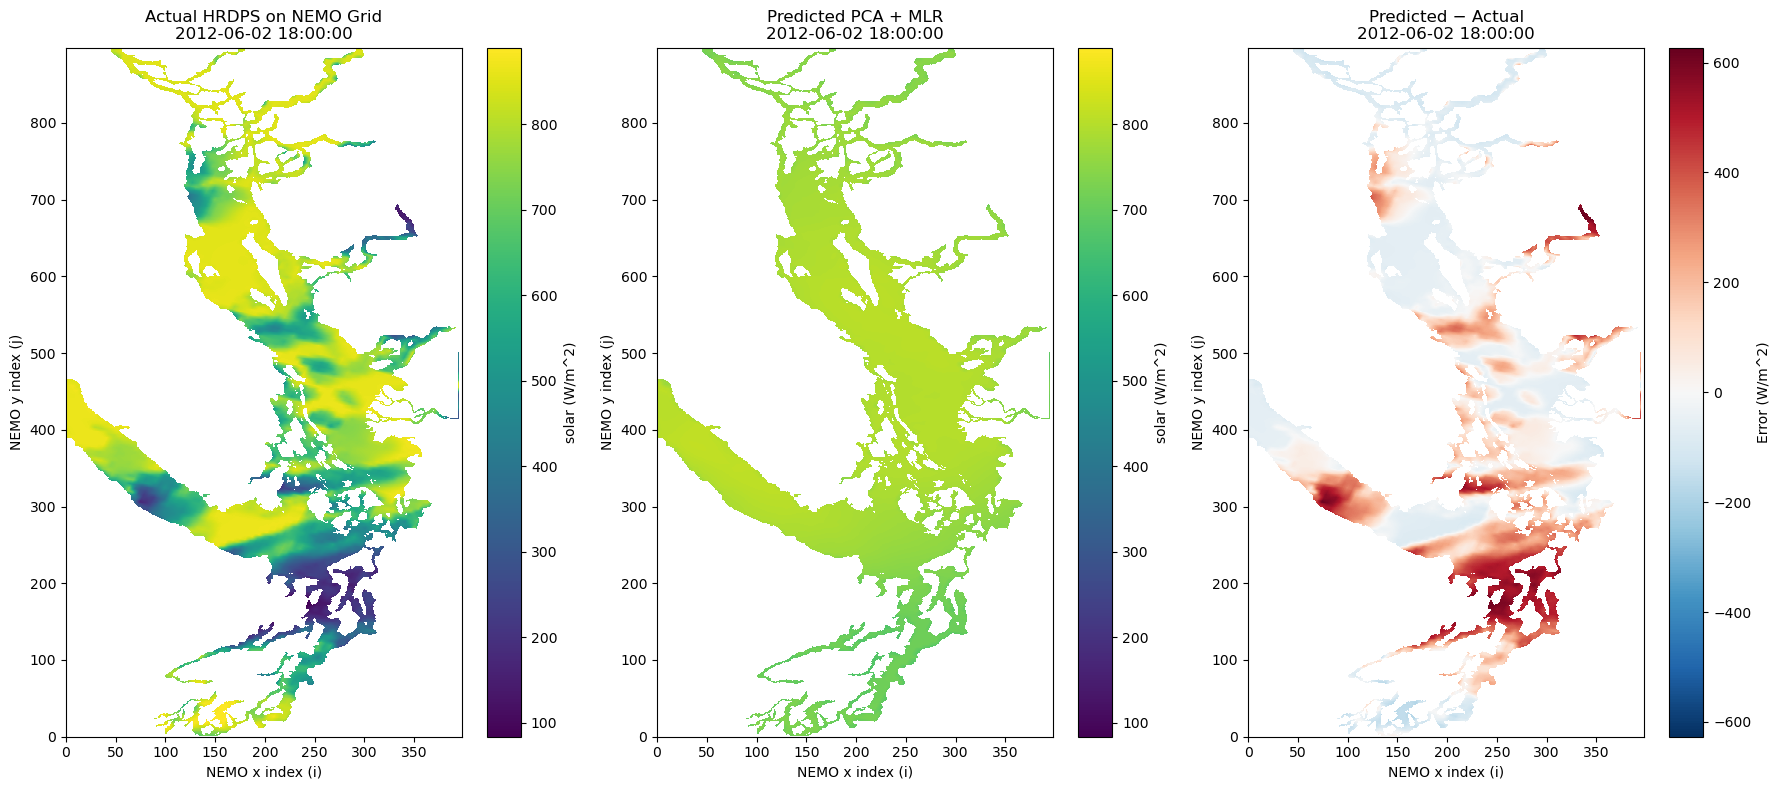

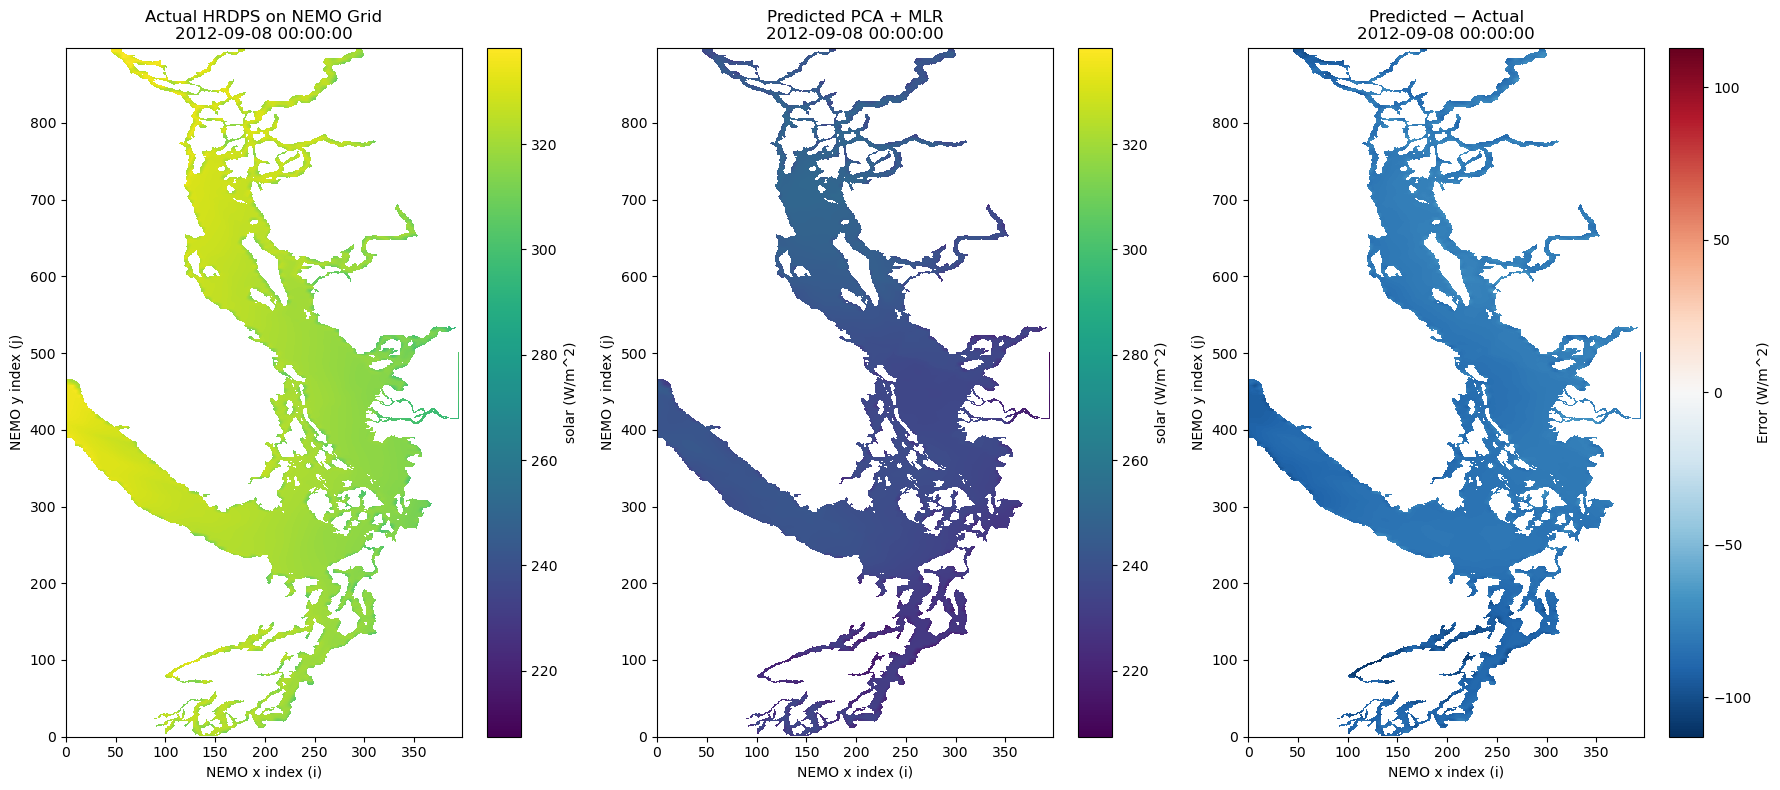

In [49]:
test_times = ds_hrdps_test["time_counter"].values

plot_actual_predicted_error(
    time_index=0,
    X_actual=X_hrdps_test,
    X_predicted=X_hrdps_test_pred,
    times=test_times
)

plot_actual_predicted_error(
    time_index=1222,
    X_actual=X_hrdps_test,
    X_predicted=X_hrdps_test_pred,
    times=test_times
)

plot_actual_predicted_error(
    time_index=2000,
    X_actual=X_hrdps_test,
    X_predicted=X_hrdps_test_pred,
    times=test_times
)

In [50]:
def make_spatial_mean_timeseries(actual_matrix,predicted_matrix,times):
    actual_mean = np.mean(actual_matrix,axis=1)
    predicted_mean = np.mean(predicted_matrix,axis=1)
    timeseries = pd.DataFrame({"actual": actual_mean,"predicted": predicted_mean},index=pd.to_datetime(times))
    timeseries.index.name = "Date"
    return timeseries

In [51]:
val_times = ds_hrdps_val["time_counter"].values
test_times = ds_hrdps_test["time_counter"].values

solar_timeseries_2008 = make_spatial_mean_timeseries(
    actual_matrix=X_hrdps_val,
    predicted_matrix=X_hrdps_val_pred,
    times=val_times
)

solar_timeseries_2012 = make_spatial_mean_timeseries(
    actual_matrix=X_hrdps_test,
    predicted_matrix=X_hrdps_test_pred,
    times=test_times
)

print(solar_timeseries_2008.head())
print()
print(solar_timeseries_2012.head())

                        actual  predicted
Date                                     
2008-01-01 00:00:00  34.370464  11.796391
2008-01-01 03:00:00   0.000000   5.894544
2008-01-01 06:00:00   0.000000   5.894544
2008-01-01 09:00:00   0.000000   5.894544
2008-01-01 12:00:00   0.000000   5.894544

                        actual  predicted
Date                                     
2012-01-01 00:00:00  21.779251   9.834623
2012-01-01 03:00:00   0.000000   5.894544
2012-01-01 06:00:00   0.000000   5.894544
2012-01-01 09:00:00   0.000000   5.894544
2012-01-01 12:00:00   0.000000   5.894544


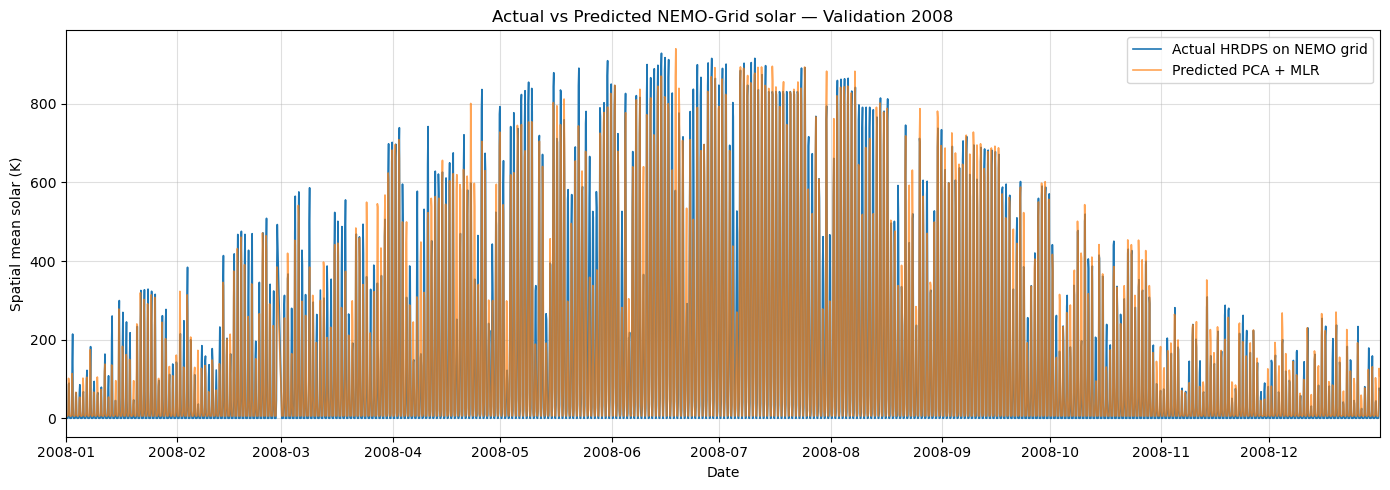

In [52]:
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(solar_timeseries_2008.index,solar_timeseries_2008["actual"],label="Actual HRDPS on NEMO grid",linewidth=1.2)
ax.plot(solar_timeseries_2008.index,solar_timeseries_2008["predicted"],label="Predicted PCA + MLR",linewidth=1.2,alpha=0.7)
ax.set_xlim(pd.Timestamp("2008-01-01"),pd.Timestamp("2008-12-31 23:59:59"))
ax.set_xlabel("Date")
ax.set_ylabel("Spatial mean solar (K)")
ax.set_title("Actual vs Predicted NEMO-Grid solar — Validation 2008")
ax.legend()
ax.grid(True, alpha=0.4)
plt.tight_layout()
plt.show()

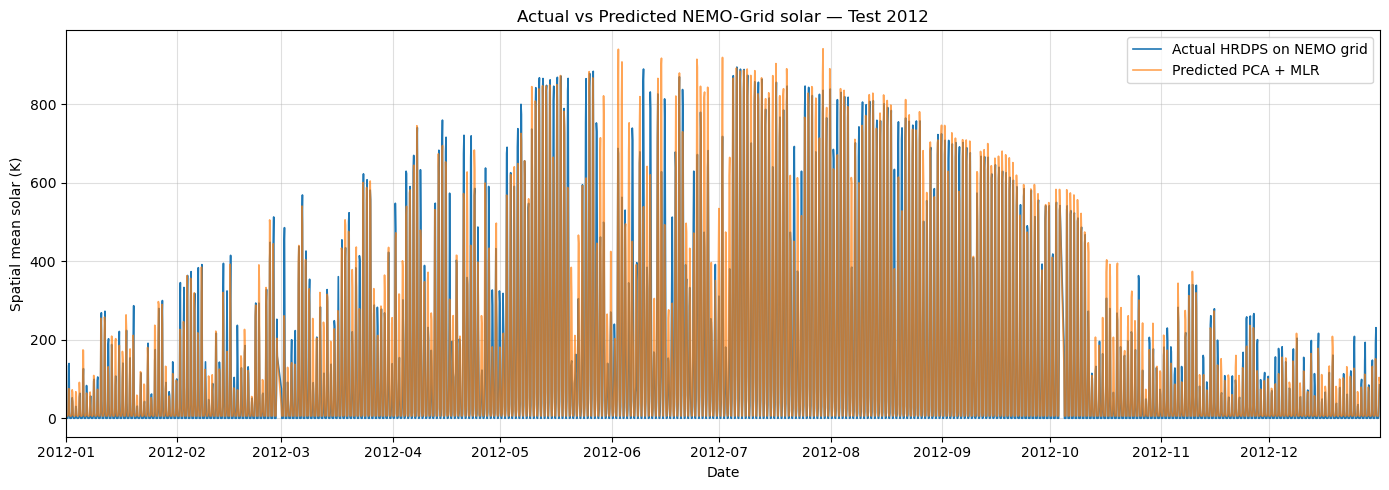

In [53]:
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(solar_timeseries_2012.index,solar_timeseries_2012["actual"],label="Actual HRDPS on NEMO grid",linewidth=1.2)
ax.plot(solar_timeseries_2012.index,solar_timeseries_2012["predicted"],label="Predicted PCA + MLR",linewidth=1.2,alpha=0.7)
ax.set_xlim(pd.Timestamp("2012-01-01"),pd.Timestamp("2012-12-31 23:59:59"))
ax.set_xlabel("Date")
ax.set_ylabel("Spatial mean solar (K)")
ax.set_title("Actual vs Predicted NEMO-Grid solar — Test 2012")
ax.legend()
ax.grid(True, alpha=0.4)
plt.tight_layout()
plt.show()

In [54]:
stations = {"Sand Heads": {"j": 426,"i": 293},
    "Halibut Bank": {"j": 503,"i": 261},
    "Sentry Shoal": {"j": 707,"i": 145}}

In [55]:
def find_station_column(station_j, station_i):
    matches = np.where((valid_nemo_j == station_j)& (valid_nemo_i == station_i))[0]
    return int(matches[0])

for station_name, station_info in stations.items():
    column = find_station_column(station_info["j"],station_info["i"])
    stations[station_name]["column"] = column
    print(station_name,"j =", station_info["j"],"i =", station_info["i"],"matrix column =", column)

Sand Heads j = 426 i = 293 matrix column = 44165
Halibut Bank j = 503 i = 261 matrix column = 53329
Sentry Shoal j = 707 i = 145 matrix column = 71870


In [56]:
test_times = pd.to_datetime(ds_hrdps_test["time_counter"].values)
station_timeseries = {}
station_rmse = {}
station_normalized_rmse = {}

for station_name, station_info in stations.items():
    column = station_info["column"]

    actual = X_hrdps_test[:, column]
    predicted = X_hrdps_test_pred[:, column]

    station_df = pd.DataFrame({"actual": actual,"predicted": predicted},index=test_times)
    station_df.index.name = "Date"
    rmse = np.sqrt(mean_squared_error(station_df["actual"],station_df["predicted"]))
    actual_std = np.std(station_df["actual"],ddof=0)
    normalized_rmse = rmse / actual_std
    station_timeseries[station_name] = station_df
    station_rmse[station_name] = rmse
    station_normalized_rmse[station_name] = normalized_rmse
    print(f"{station_name} RMSE: {rmse:.4f} ")
    print(f"{station_name} Normalized RMSE: {normalized_rmse:.4f} ({normalized_rmse * 100:.2f}%)")

Sand Heads RMSE: 88.2739 
Sand Heads Normalized RMSE: 0.3802 (38.02%)
Halibut Bank RMSE: 84.5604 
Halibut Bank Normalized RMSE: 0.3669 (36.69%)
Sentry Shoal RMSE: 83.2799 
Sentry Shoal Normalized RMSE: 0.3665 (36.65%)


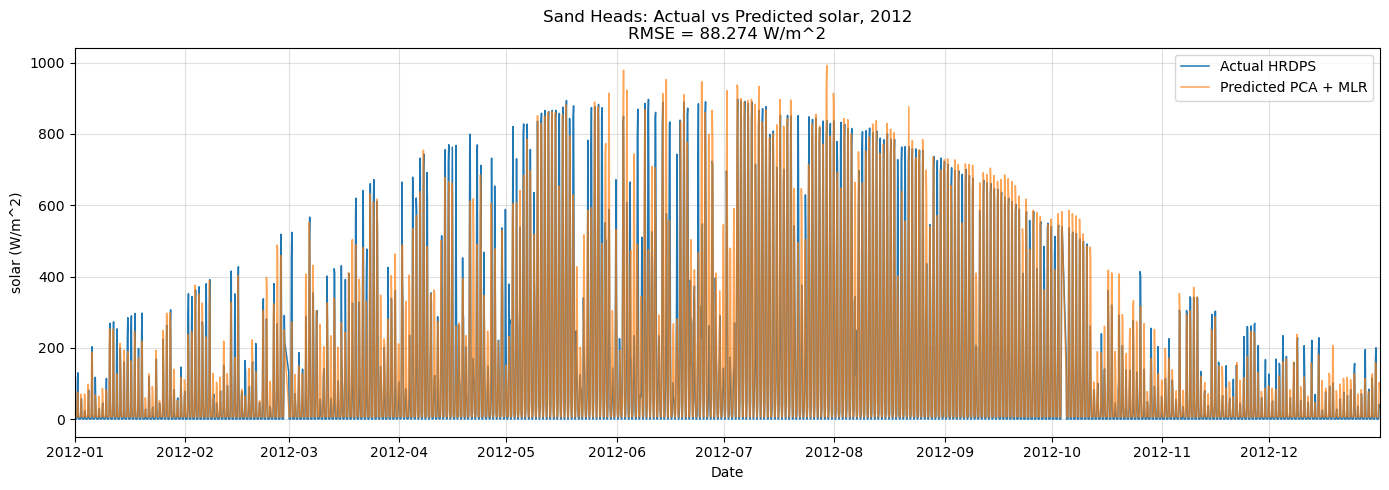

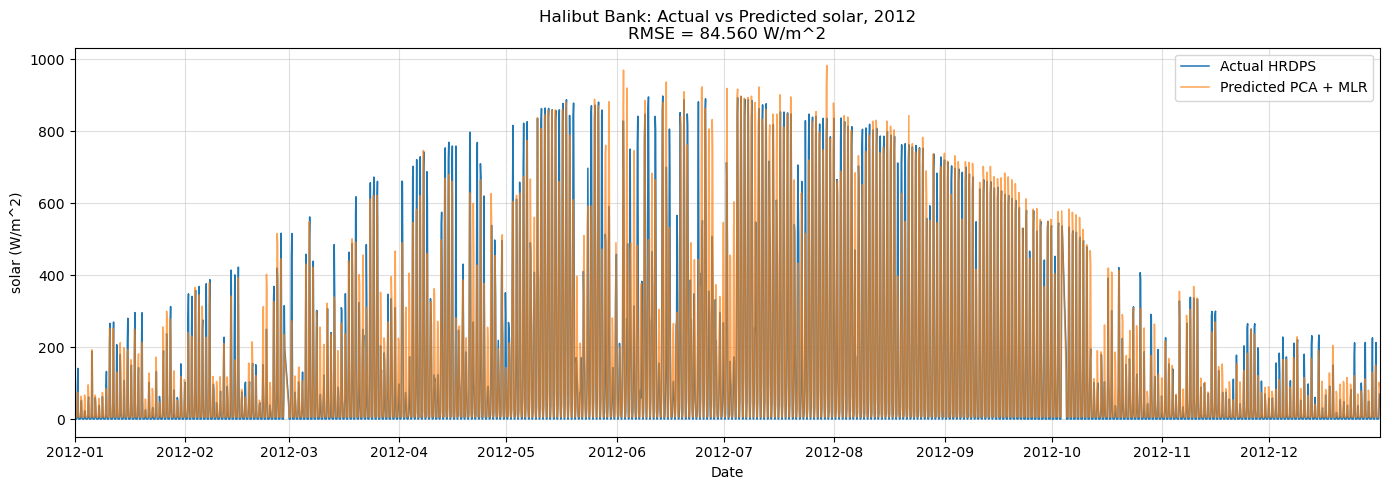

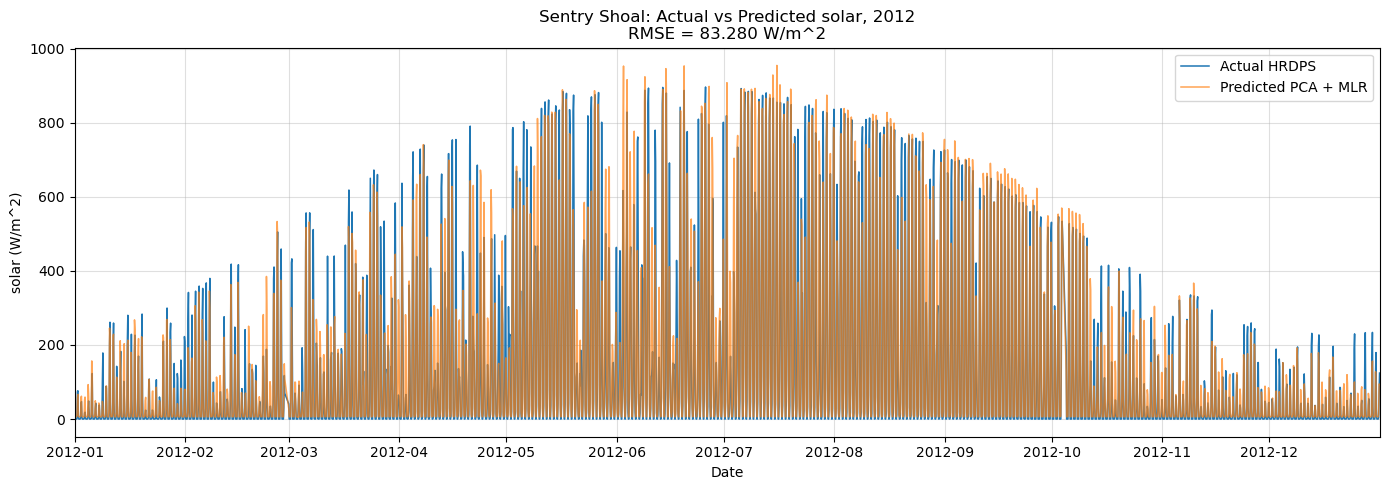

In [57]:
for station_name, station_df in station_timeseries.items():
    fig, ax = plt.subplots(figsize=(14, 5))
    ax.plot(station_df.index,station_df["actual"],label="Actual HRDPS",linewidth=1.1)
    ax.plot(station_df.index,station_df["predicted"],label="Predicted PCA + MLR",linewidth=1.1,alpha=0.7)
    ax.set_xlim(pd.Timestamp("2012-01-01"),pd.Timestamp("2012-12-31 23:59:59"))
    ax.set_xlabel("Date")
    ax.set_ylabel("solar (W/m^2)")
    ax.set_title(f"{station_name}: Actual vs Predicted solar, 2012\n"f"RMSE = {station_rmse[station_name]:.3f} W/m^2")
    ax.legend()
    ax.grid(True, alpha=0.4)
    plt.tight_layout()
    plt.show()

In [58]:
station_rmse_table = pd.DataFrame({"Station": list(station_rmse.keys()),"RMSE_K": list(station_rmse.values()),"Normalized_RMSE": list(station_normalized_rmse.values())})
station_rmse_table["Normalized_RMSE_Percent"] = station_rmse_table["Normalized_RMSE"] * 100
average_station_rmse = station_rmse_table["RMSE_K"].mean()
average_station_normalized_rmse = station_rmse_table["Normalized_RMSE"].mean()
print(station_rmse_table.to_string(index=False))
print(f"\nAverage RMSE across the three stations: {average_station_rmse:.4f}")
print(f"Average normalized RMSE across the three stations: {average_station_normalized_rmse:.4f} ({average_station_normalized_rmse * 100:.2f}%)")

     Station    RMSE_K  Normalized_RMSE  Normalized_RMSE_Percent
  Sand Heads 88.273935         0.380163                38.016290
Halibut Bank 84.560441         0.366891                36.689114
Sentry Shoal 83.279910         0.366469                36.646860

Average RMSE across the three stations: 85.3714
Average normalized RMSE across the three stations: 0.3712 (37.12%)


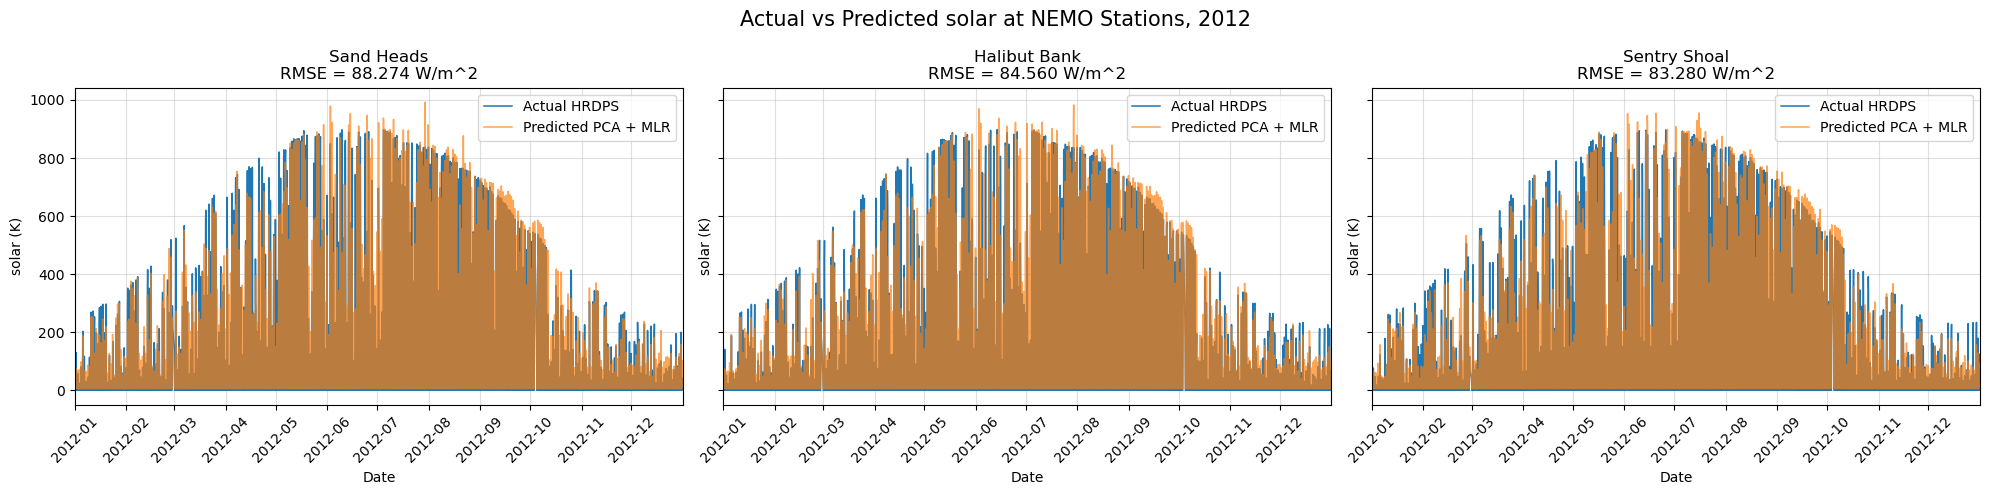

In [59]:
fig, axes = plt.subplots(1,3,figsize=(20, 5),sharey=True)
for ax, (station_name, station_df) in zip(axes,station_timeseries.items()):
    ax.plot(station_df.index,station_df["actual"],label="Actual HRDPS",linewidth=1.1)
    ax.plot(station_df.index,station_df["predicted"],label="Predicted PCA + MLR",linewidth=1.1,alpha=0.7)
    ax.set_xlim(pd.Timestamp("2012-01-01"),pd.Timestamp("2012-12-31 23:59:59"))
    ax.set_xlabel("Date")
    ax.set_ylabel("solar (K)")
    ax.set_title(f"{station_name}\n"f"RMSE = {station_rmse[station_name]:.3f} W/m^2")
    ax.legend()
    ax.grid(True, alpha=0.4)
    ax.tick_params(axis="x",rotation=45)

fig.suptitle(
    "Actual vs Predicted solar at NEMO Stations, 2012",
    fontsize=15
)

plt.tight_layout()
plt.show()

In [60]:
from pathlib import Path
import netCDF4 as nc

In [61]:
output_directory = Path("/ocean/dtaneja/MOAD/analysis-dishika/notebooks/results/pca_lr_predictions_2008_final")
output_directory.mkdir(parents=True, exist_ok=True)
solar_output_file = output_directory / "pred_solar_2008.nc"

In [62]:
solar_predictions = np.asarray(X_hrdps_val_pred,dtype=np.float32,)
validation_times = pd.DatetimeIndex(pd.to_datetime(ds_hrdps_val["time_counter"].values))
ny, nx = water_mask.shape
print("Predictions:", solar_predictions.shape)
print("NEMO grid:", ny, nx)
print("Validation times:", len(validation_times))

Predictions: (2920, 81383)
NEMO grid: 898 398
Validation times: 2920


In [63]:
fill_value = np.float32(1e20)

with nc.Dataset(solar_output_file, mode="w", format="NETCDF4") as output_nc:

    # Dimensions
    output_nc.createDimension("time_counter", None)
    output_nc.createDimension("y", ny)
    output_nc.createDimension("x", nx)

    # Coordinate variables
    time_variable = output_nc.createVariable("time_counter", "f8", ("time_counter",))
    y_variable = output_nc.createVariable("y", "i4", ("y",))
    x_variable = output_nc.createVariable("x", "i4", ("x",))
    nav_lat_variable = output_nc.createVariable("nav_lat", "f4", ("y", "x"), zlib=True, complevel=4)
    nav_lon_variable = output_nc.createVariable("nav_lon", "f4", ("y", "x"), zlib=True, complevel=4)
    tmask_variable = output_nc.createVariable("tmask", "i1", ("y", "x"), zlib=True, complevel=4)

    # Shortwave radiation variable
    solar_variable = output_nc.createVariable("solar", "f4", ("time_counter", "y", "x"), fill_value=fill_value, zlib=True, complevel=4, shuffle=True, chunksizes=(8, min(200, ny), min(200, nx)))

    # Time metadata
    time_variable.units = "seconds since 1970-01-01 00:00:00"
    time_variable.calendar = "standard"
    time_variable.standard_name = "time"
    time_variable.long_name = "time"

    # Spatial-coordinate metadata
    nav_lat_variable.units = "degrees_north"
    nav_lat_variable.standard_name = "latitude"
    nav_lat_variable.long_name = "latitude"
    nav_lon_variable.units = "degrees_east"
    nav_lon_variable.standard_name = "longitude"
    nav_lon_variable.long_name = "longitude"
    tmask_variable.long_name = "NEMO surface water mask"
    tmask_variable.flag_values = np.array([0, 1], dtype=np.int8)
    tmask_variable.flag_meanings = "land water"

    # Solar metadata
    solar_variable.units = "W m-2"
    solar_variable.standard_name = "net_downward_shortwave_flux_in_air"
    solar_variable.long_name = "PCA and multiple linear regression downscaled shortwave radiation"
    solar_variable.coordinates = "time_counter nav_lat nav_lon"
    solar_variable.grid = "SalishSeaCast NEMO grid"
    solar_variable.prediction_method = "PCA plus multiple linear regression"

    # Global metadata
    output_nc.title = "PCA and linear regression downscaled shortwave radiation for 2008"
    output_nc.notebook_github_url = "https://github.com/SalishSeaCast/analysis-dishika/blob/main/notebooks/PCA_new_grid/solar.ipynb"
    output_nc.data_split = "validation"
    output_nc.year = 2008
    output_nc.time_resolution = "3-hourly"
    output_nc.selected_hrdps_pcs = int(n_hrdps_pcs)
    output_nc.selected_canrcm_pcs = int(n_canrcm_pcs)
    output_nc.note = "Predictions are available at retained NEMO water cells. Land cells and excluded water cells contain the fill value."

    # Write coordinates
    y_variable[:] = np.arange(ny, dtype=np.int32)
    x_variable[:] = np.arange(nx, dtype=np.int32)
    nav_lat_variable[:, :] = nemo_lat_2d.astype(np.float32)
    nav_lon_variable[:, :] = nemo_lon_2d.astype(np.float32)
    tmask_variable[:, :] = water_mask.astype(np.int8)

    python_times = validation_times.to_pydatetime()
    time_variable[:] = nc.date2num(python_times, units=time_variable.units, calendar=time_variable.calendar)

    # Write eight 3-hourly predictions at a time
    number_of_times = solar_predictions.shape[0]
    batch_size = 8

    for start_index in range(0, number_of_times, batch_size):
        end_index = min(start_index + batch_size, number_of_times)
        current_batch_size = end_index - start_index
        full_grid_batch = np.full((current_batch_size, ny, nx), fill_value, dtype=np.float32)
        full_grid_batch[:, valid_nemo_j, valid_nemo_i] = solar_predictions[start_index:end_index]
        solar_variable[start_index:end_index, :, :] = full_grid_batch
        print(f"Written timestamps: {end_index}/{number_of_times}", end="\r")

print("\nShortwave Radiation file saved to:")
print(solar_output_file)

Written timestamps: 2920/2920
Shortwave Radiation file saved to:
/ocean/dtaneja/MOAD/analysis-dishika/notebooks/results/pca_lr_predictions_2008_final/pred_solar_2008.nc


In [64]:
ds_solar_check = xr.open_dataset(solar_output_file)

print(ds_solar_check)
print("Solar dimensions:", ds_solar_check["solar"].dims)
print("Solar shape:", ds_solar_check["solar"].shape)

ds_solar_check.close()

<xarray.Dataset> Size: 4GB
Dimensions:       (y: 898, x: 398, time_counter: 2920)
Coordinates:
  * y             (y) int32 4kB 0 1 2 3 4 5 6 7 ... 891 892 893 894 895 896 897
  * x             (x) int32 2kB 0 1 2 3 4 5 6 7 ... 391 392 393 394 395 396 397
    nav_lat       (y, x) float32 1MB ...
    nav_lon       (y, x) float32 1MB ...
  * time_counter  (time_counter) datetime64[ns] 23kB 2008-01-01 ... 2008-12-3...
Data variables:
    tmask         (y, x) int8 357kB ...
    solar         (time_counter, y, x) float32 4GB ...
Attributes:
    title:                PCA and linear regression downscaled shortwave radi...
    notebook_github_url:  https://github.com/SalishSeaCast/analysis-dishika/b...
    data_split:           validation
    year:                 2008
    time_resolution:      3-hourly
    selected_hrdps_pcs:   5
    selected_canrcm_pcs:  93
    note:                 Predictions are available at retained NEMO water ce...
Solar dimensions: ('time_counter', 'y', 'x')
Solar shape

In [65]:
first_solar_map = ds_solar_check["solar"].isel(time_counter=0).values

print(first_solar_map.shape)
print("Finite cells:", np.isfinite(first_solar_map).sum())
print("Minimum:", np.nanmin(first_solar_map))
print("Maximum:", np.nanmax(first_solar_map))

ds_solar_check.close()

(898, 398)
Finite cells: 81383
Minimum: 7.658493
Maximum: 15.095795


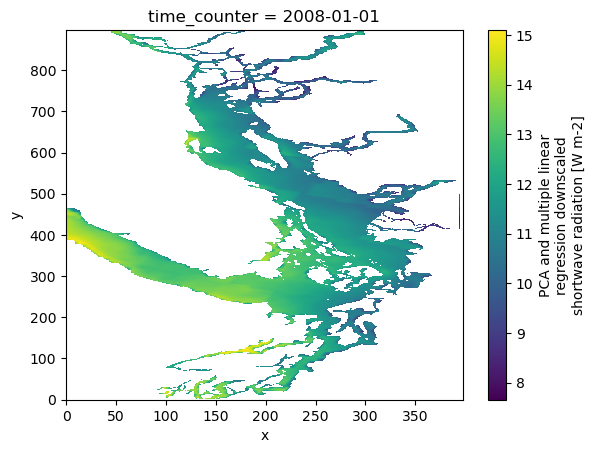

In [66]:
ds_solar_check["solar"].isel(time_counter=0).plot()

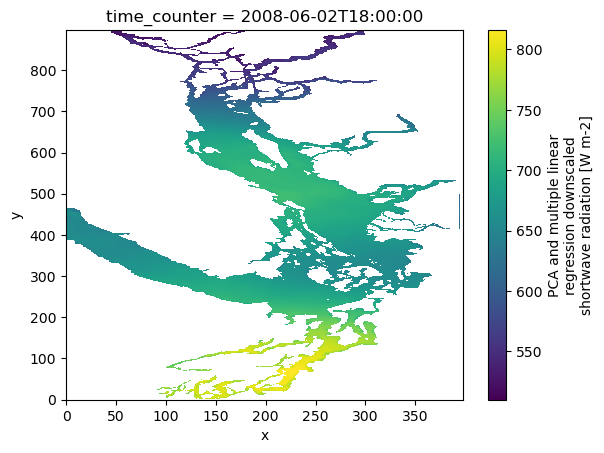

In [67]:
ds_solar_check["solar"].isel(time_counter=1222).plot()

In [68]:
print(ds_solar_check["time_counter"].values[0])
print(ds_solar_check["time_counter"].values[1])
print(ds_solar_check["time_counter"].values[2])
print(ds_solar_check["time_counter"].values[-2])
print(ds_solar_check["time_counter"].values[-1])

2008-01-01T00:00:00.000000000
2008-01-01T03:00:00.000000000
2008-01-01T06:00:00.000000000
2008-12-31T18:00:00.000000000
2008-12-31T21:00:00.000000000
